# Delamanid stable graphs

Stability selection results for CMM-logistic on TB delamanid data (lineage-stratified). Loads `results/tb_subsample_dlm_lineage_*/edge_stability.csv` and visualizes the stable BN at conventional and conservative thresholds.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))
sys.path.insert(0, str(Path.cwd().parents[2] / 'external' / 'cmm'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import json
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import pandas as pd
from src_tb.causal_recovery.cmm_utils import visualize_stable_bn

RESULTS = Path.cwd().parents[2] / 'results' / 'subsampling' / 'tb_subsample_dlm_lineage_mp4_k6_mcc4'
df = pd.read_csv(RESULTS / 'edge_stability.csv')
df.head()

,source,target,count,n_eligible,frequency
0,lineage_2,fgd1_Lys270Met,1,1,1.00
1,lineage_4,mmpl5_Thr794Ile,99,100,0.99
2,lineage_4,fgd1_Phe320Phe,99,100,0.99
3,lineage_2,mmpl5_Asp767Asn,95,100,0.95
4,lineage_2,rv0678_G*128C,84,100,0.84


## Stable graph (frequency ≥ 0.5)

Meinshausen–Bühlmann convention: edges retained more often than chance across stability-selection runs.

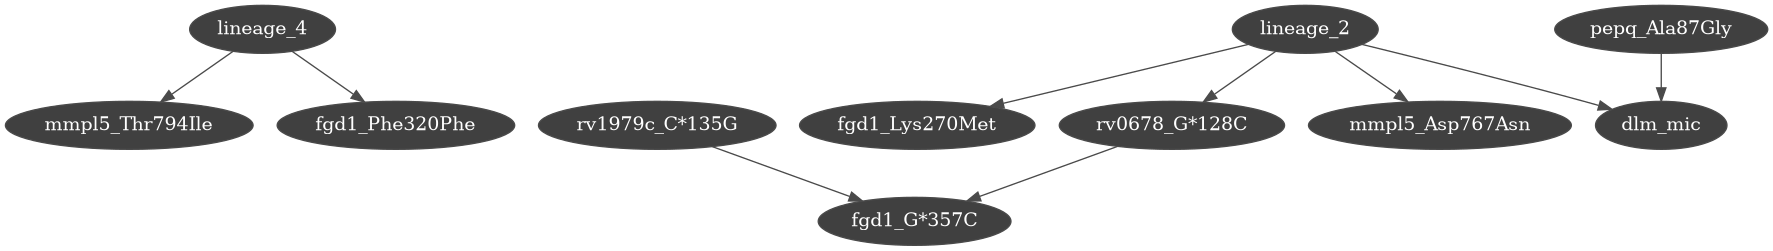

In [9]:
visualize_stable_bn(df, threshold=0.5, continuous_features=['dlm_mic'], size='20')

## Conservative cut (frequency ≥ 0.7)

Tighter threshold: structural backbone (high-confidence lineage→mutation co-occurrence and strong mutation→mutation edges).

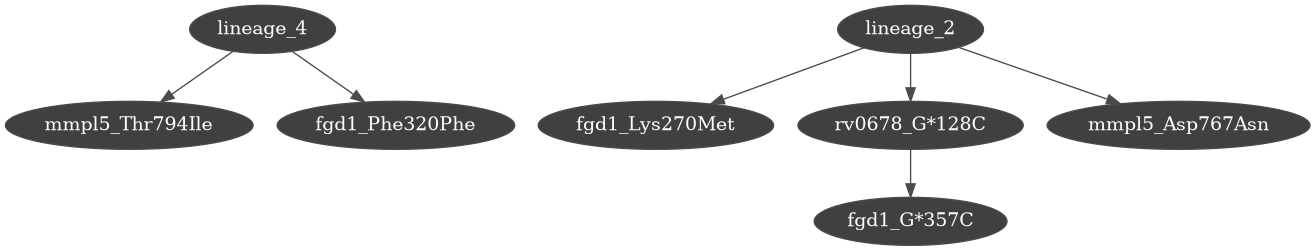

In [10]:
visualize_stable_bn(df, threshold=0.7, continuous_features=['dlm_mic'], size='20')

## Top edges

All edges with frequency ≥ 0.3, sorted by frequency. `n_eligible` is the number of subsample runs in which both endpoints were present.

In [11]:
df.sort_values('frequency', ascending=False).query('frequency >= 0.3').reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,lineage_2,fgd1_Lys270Met,1,1,1.000000
1,lineage_4,mmpl5_Thr794Ile,99,100,0.990000
2,lineage_4,fgd1_Phe320Phe,99,100,0.990000
3,lineage_2,mmpl5_Asp767Asn,95,100,0.950000
4,lineage_2,rv0678_G*128C,84,100,0.840000
5,rv0678_G*128C,fgd1_G*357C,76,100,0.760000
6,rv1979c_C*135G,fgd1_G*357C,57,95,0.600000
7,lineage_2,dlm_mic,52,100,0.520000
8,pepq_Ala87Gly,dlm_mic,51,100,0.510000
9,lineage_4,fgd1_G*357C,46,100,0.460000


## Direct MIC drivers

Edges with `dlm_mic` as target.

In [12]:
df[df['target'] == 'dlm_mic'].sort_values('frequency', ascending=False).reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,lineage_2,dlm_mic,52,100,0.520000
1,pepq_Ala87Gly,dlm_mic,51,100,0.510000
2,rv1979c_C*135G,dlm_mic,37,95,0.389474
3,lineage_4,dlm_mic,12,100,0.120000
4,mmpl5_Asp767Asn,dlm_mic,8,100,0.080000
5,rv0678_G*128C,dlm_mic,6,100,0.060000
6,fgd1_G*357C,dlm_mic,5,100,0.050000
7,mmpl5_Thr794Ile,dlm_mic,2,100,0.020000
8,mmpl5_Ile948Val,dlm_mic,1,100,0.010000


**Note on the efflux co-occurrence cluster.** At |r| > 0.5, the prevalent mutations form a single co-occurrence cluster: `rv0678_G*128C`, `mmpl5_Asp767Asn`, `mmpl5_Thr794Ile`, `rv1979c_C*135G`, `fgd1_G*357C`, `fgd1_Phe320Phe` (see `data_exploration.ipynb`). Stability credit is split across these members across subsamples. Summing the MIC-edge frequencies within the cluster gives ~0.62, slightly above the singleton `pepq_Ala87Gly` at 0.51. Reading individual frequencies for cluster members in isolation understates the underlying signal; the cluster's total stability is the more interpretable quantity.

## Per-node k summary

Best k chosen per node across stability-selection runs. Binary nodes typically pin at k=1 (no mixture structure); the continuous outcome (`dlm_mic`) is where higher k indicates non-Gaussian conditional distributions.

In [8]:
pd.read_csv(RESULTS / 'per_node_k.csv')

,feature,n_runs_present,k1_count,k2_count,k3_count,k4_count,k5_count,k6_count,mean_k,median_k,mode_k
0,dlm_mic,100,0,0,0,19,31,50,5.31,5.5,6
1,pepq_Ala87Gly,100,97,2,1,0,0,0,1.04,1.0,1
2,lineage_4,100,99,0,0,0,1,0,1.04,1.0,1
3,rv0678_G*128C,100,100,0,0,0,0,0,1.00,1.0,1
4,mmpl5_Ile948Val,100,100,0,0,0,0,0,1.00,1.0,1
5,mmpl5_Asp767Asn,100,100,0,0,0,0,0,1.00,1.0,1
6,rv1979c_C*135G,95,95,0,0,0,0,0,1.00,1.0,1
7,mmpl5_Thr794Ile,100,100,0,0,0,0,0,1.00,1.0,1
8,fgd1_G*357C,100,100,0,0,0,0,0,1.00,1.0,1
9,fgd1_Phe320Phe,100,100,0,0,0,0,0,1.00,1.0,1
